# 📡 MTN Ghana — Business Intelligence & Customer Churn Prediction

---

**What this project does:**
1. **Understand** how MTN customers behave using Business Intelligence (BI)
2. **Identify** the main reasons customers are leaving (churning)
3. **Predict** which customers are likely to leave next using Machine Learning
4. **Recommend** actions MTN can take to keep customers

**Dataset:** 974 MTN Ghana customers | 17 columns  
**Target:** `Customer Churn Status` — Did the customer leave? (Yes / No)

---
## Step 1 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Clean plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

YELLOW = '#FFCB05'   # MTN Yellow
BLUE   = '#003087'   # MTN Blue
RED    = '#E63946'
GREEN  = '#2DC653'

print('✅ All libraries loaded.')

✅ All libraries loaded.


---
## Step 2 — Load & Understand the Data

In [7]:
df = pd.read_csv('mtn_high_risk_customers.csv')

print(f'Total records : {df.shape[0]}')
print(f'Total columns : {df.shape[1]}')
print()
print('Column names:')
for col in df.columns:
    print(f'  • {col}')

Total records : 214
Total columns : 13

Column names:
  • Customer ID
  • Full Name
  • Gender
  • Age
  • MTN Device
  • Subscription Plan
  • Customer Tenure in months
  • Satisfaction Rate
  • Customer Review
  • Total Revenue
  • Customer Churn Status
  • Churn Probability (%)
  • Risk Level


In [8]:
# View the first 5 rows
df.head()

,Customer ID,Full Name,Gender,Age,MTN Device,Subscription Plan,Customer Tenure in months,Satisfaction Rate,Customer Review,Total Revenue,Customer Churn Status,Churn Probability (%),Risk Level
0,CUST0479,Ejiro Stewart,Female,20,Mobile SIM Card,16.5GB+10mins Monthly Plan,58,1,Poor,117000,Yes,89.0,High Risk
1,CUST0035,Oghene Mcguire,Male,44,4G Router,165GB Monthly Plan,49,2,Fair,665000,Yes,87.0,High Risk
2,CUST0248,Boma Peterson,Female,56,Mobile SIM Card,3.2GB 2-Day Plan,44,5,Excellent,15000,Yes,87.0,High Risk
3,CUST0112,Bala Smith,Male,62,5G Broadband Router,60GB Monthly Broadband Plan,25,5,Excellent,188500,Yes,87.0,High Risk
4,CUST0364,Maryam Harmon,Female,79,4G Router,165GB Monthly Plan,2,3,Good,630000,Yes,86.0,High Risk


In [9]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer ID                214 non-null    object 
 1   Full Name                  214 non-null    object 
 2   Gender                     214 non-null    object 
 3   Age                        214 non-null    int64  
 4   MTN Device                 214 non-null    object 
 5   Subscription Plan          214 non-null    object 
 6   Customer Tenure in months  214 non-null    int64  
 7   Satisfaction Rate          214 non-null    int64  
 8   Customer Review            214 non-null    object 
 9   Total Revenue              214 non-null    int64  
 10  Customer Churn Status      214 non-null    object 
 11  Churn Probability (%)      214 non-null    float64
 12  Risk Level                 214 non-null    object 
dtypes: float64(1), int64(4), object(8)
memory usage: 2

In [5]:
# Summary statistics for numeric columns
df[['Age', 'Satisfaction Rate', 'Customer Tenure in months',
    'Unit Price', 'Number of Times Purchased',
    'Total Revenue', 'Data Usage']].describe().round(1)

,Age,Satisfaction Rate,Customer Tenure in months,Unit Price,Number of Times Purchased,Total Revenue,Data Usage
count,974.0,974.0,974.0,974.0,974.0,974.0,974.0
mean,48.0,2.9,31.4,19196.7,10.6,204669.6,99.3
std,17.8,1.4,17.2,25586.7,5.7,324785.5,57.7
min,16.0,1.0,1.0,350.0,1.0,350.0,0.8
25%,32.0,2.0,17.0,5500.0,5.0,33000.0,47.6
50%,49.0,3.0,31.0,14500.0,11.0,108000.0,103.3
75%,63.8,4.0,47.0,24000.0,15.0,261000.0,149.7
max,80.0,5.0,60.0,150000.0,20.0,3000000.0,200.0


In [6]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())
print()
print("Note: 'Reasons for Churn' is blank for customers who did NOT churn — this is correct.")

Missing values per column:
Customer ID                    0
Full Name                      0
Date of Purchase               0
Age                            0
State                          0
MTN Device                     0
Gender                         0
Satisfaction Rate              0
Customer Review                0
Customer Tenure in months      0
Subscription Plan              0
Unit Price                     0
Number of Times Purchased      0
Total Revenue                  0
Data Usage                     0
Customer Churn Status          0
Reasons for Churn            690
dtype: int64

Note: 'Reasons for Churn' is blank for customers who did NOT churn — this is correct.


---
## Step 3 — Business Intelligence: Exploratory Analysis

> Here we answer the question: *What patterns exist in the data?*

### 3.1 — Overall Churn Rate

Retained customers : 690  (70.8%)
Churned  customers : 284   (29.2%)
Total              : 974


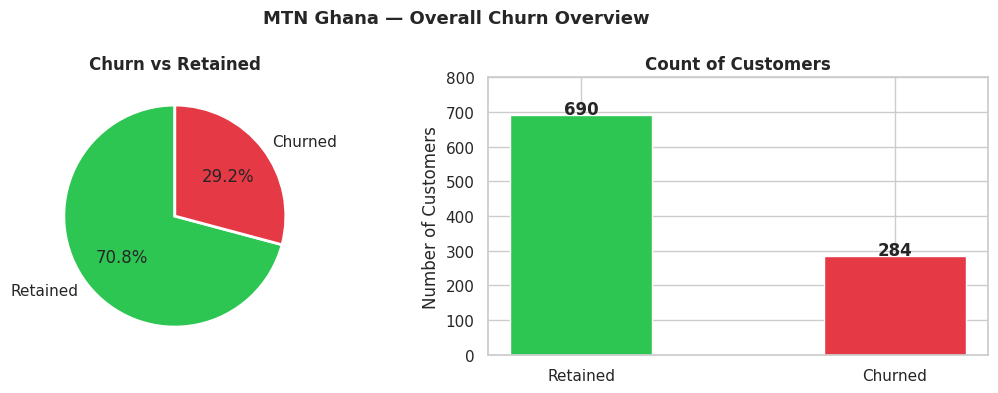


📌 Insight: About 1 in 3 MTN customers has churned. This is a serious retention problem.


In [7]:
churn_counts = df['Customer Churn Status'].value_counts()
churn_rate   = churn_counts['Yes'] / len(df) * 100

print(f'Retained customers : {churn_counts["No"]}  ({100-churn_rate:.1f}%)')
print(f'Churned  customers : {churn_counts["Yes"]}   ({churn_rate:.1f}%)')
print(f'Total              : {len(df)}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie chart
axes[0].pie(
    churn_counts,
    labels=['Retained', 'Churned'],
    colors=[GREEN, RED],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Churn vs Retained', fontweight='bold')

# Bar chart
bars = axes[1].bar(['Retained', 'Churned'], churn_counts.values,
                    color=[GREEN, RED], width=0.45, edgecolor='white')
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Count of Customers', fontweight='bold')
axes[1].set_ylim(0, 800)

plt.suptitle('MTN Ghana — Overall Churn Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_churn_overview.png', bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: About 1 in 3 MTN customers has churned. This is a serious retention problem.')

### 3.2 — Why Are Customers Leaving? (Reasons for Churn)

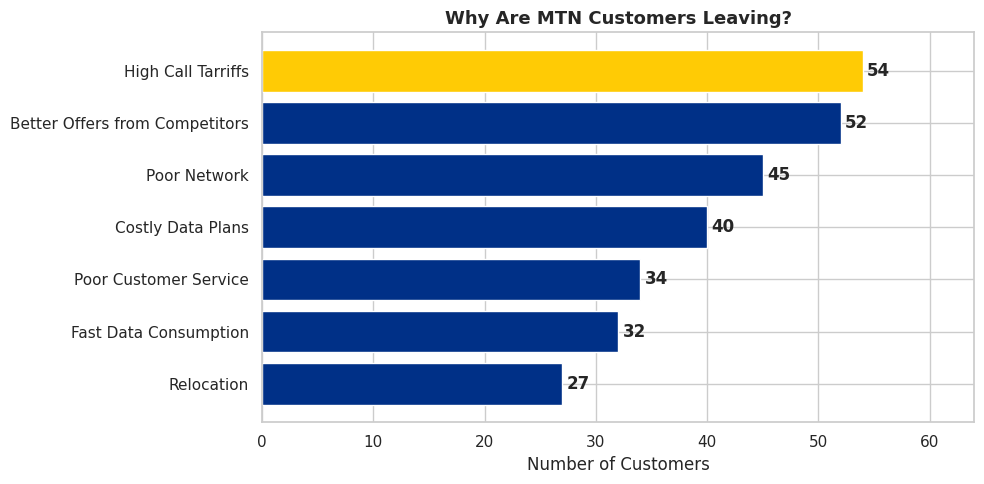

📌 Insight: The #1 reason customers leave is "High Call Tarriffs" (54 customers).
   MTN must review its call tariff pricing to stay competitive.


In [8]:
reasons = df[df['Customer Churn Status'] == 'Yes']['Reasons for Churn'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = [YELLOW if i == 0 else BLUE for i in range(len(reasons))]
bars = ax.barh(reasons.index[::-1], reasons.values[::-1],
               color=colors_r[::-1], edgecolor='white')
for bar, val in zip(bars, reasons.values[::-1]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.set_title('Why Are MTN Customers Leaving?', fontsize=13, fontweight='bold')
ax.set_xlim(0, reasons.max() + 10)
plt.tight_layout()
plt.savefig('chart2_churn_reasons.png', bbox_inches='tight')
plt.show()

top_reason = reasons.idxmax()
print(f'📌 Insight: The #1 reason customers leave is "{top_reason}" ({reasons.max()} customers).')
print('   MTN must review its call tariff pricing to stay competitive.')

### 3.3 — Satisfaction Rate vs Churn

Average Satisfaction Rate:
  Retained customers : 2.91
  Churned  customers : 3.05


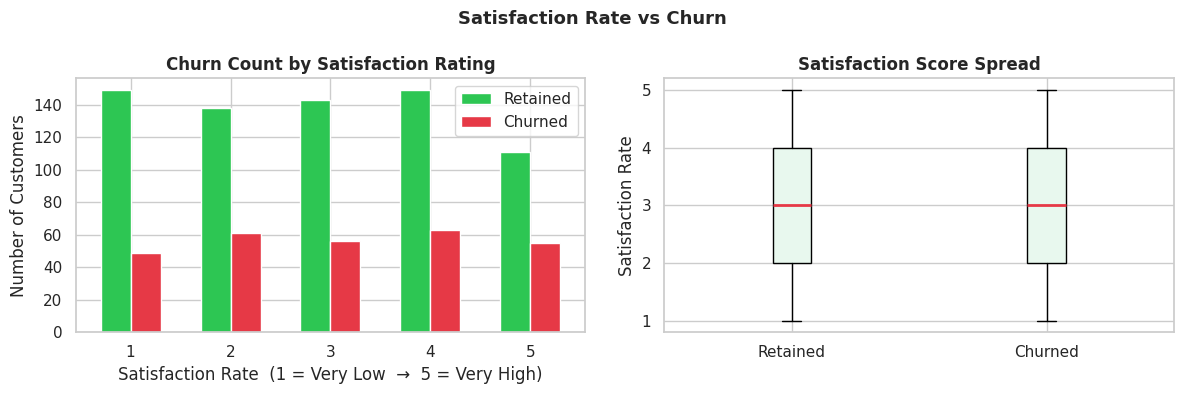


📌 Insight: Churned customers have an average satisfaction score of 3.05,
   vs 2.91 for retained customers. Low satisfaction = high churn risk.


In [9]:
# Average satisfaction: churned vs retained
avg_sat = df.groupby('Customer Churn Status')['Satisfaction Rate'].mean().round(2)
print('Average Satisfaction Rate:')
print(f'  Retained customers : {avg_sat["No"]}')
print(f'  Churned  customers : {avg_sat["Yes"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count per satisfaction score, split by churn
sat_churn = df.groupby(['Satisfaction Rate', 'Customer Churn Status']).size().unstack(fill_value=0)
sat_churn.plot(kind='bar', ax=axes[0], color=[GREEN, RED], edgecolor='white', width=0.6)
axes[0].set_title('Churn Count by Satisfaction Rating', fontweight='bold')
axes[0].set_xlabel('Satisfaction Rate  (1 = Very Low  →  5 = Very High)')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Retained', 'Churned'])

# Box plot
churned_sat  = df[df['Customer Churn Status'] == 'Yes']['Satisfaction Rate']
retained_sat = df[df['Customer Churn Status'] == 'No']['Satisfaction Rate']
axes[1].boxplot([retained_sat, churned_sat],
                labels=['Retained', 'Churned'],
                patch_artist=True,
                boxprops=dict(facecolor='#e8f8ee'),
                medianprops=dict(color=RED, linewidth=2))
axes[1].set_title('Satisfaction Score Spread', fontweight='bold')
axes[1].set_ylabel('Satisfaction Rate')

plt.suptitle('Satisfaction Rate vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_satisfaction_churn.png', bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: Churned customers have an average satisfaction score of {avg_sat["Yes"]},')
print(f'   vs {avg_sat["No"]} for retained customers. Low satisfaction = high churn risk.')

### 3.4 — Customer Tenure vs Churn

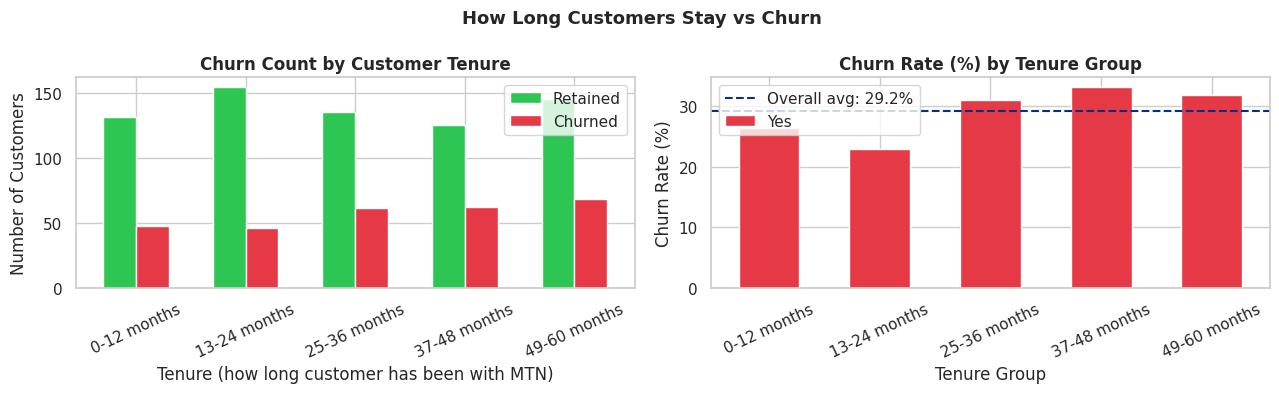

📌 Insight: Newer customers (shorter tenure) are at higher risk of churning.
   MTN should focus on early engagement programmes for new subscribers.


In [10]:
# Group tenure into ranges
df['Tenure Group'] = pd.cut(
    df['Customer Tenure in months'],
    bins=[0, 12, 24, 36, 48, 60],
    labels=['0-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months']
)

tenure_churn = df.groupby(['Tenure Group', 'Customer Churn Status']).size().unstack(fill_value=0)
tenure_pct   = tenure_churn.div(tenure_churn.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tenure_churn.plot(kind='bar', ax=axes[0], color=[GREEN, RED], edgecolor='white', width=0.6)
axes[0].set_title('Churn Count by Customer Tenure', fontweight='bold')
axes[0].set_xlabel('Tenure (how long customer has been with MTN)')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(['Retained', 'Churned'])

tenure_pct['Yes'].plot(kind='bar', ax=axes[1], color=RED, edgecolor='white', width=0.55)
axes[1].axhline(churn_rate, color=BLUE, linestyle='--', linewidth=1.5,
                label=f'Overall avg: {churn_rate:.1f}%')
axes[1].set_title('Churn Rate (%) by Tenure Group', fontweight='bold')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

plt.suptitle('How Long Customers Stay vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_tenure_churn.png', bbox_inches='tight')
plt.show()

print('📌 Insight: Newer customers (shorter tenure) are at higher risk of churning.')
print('   MTN should focus on early engagement programmes for new subscribers.')

### 3.5 — Churn by MTN Device Type

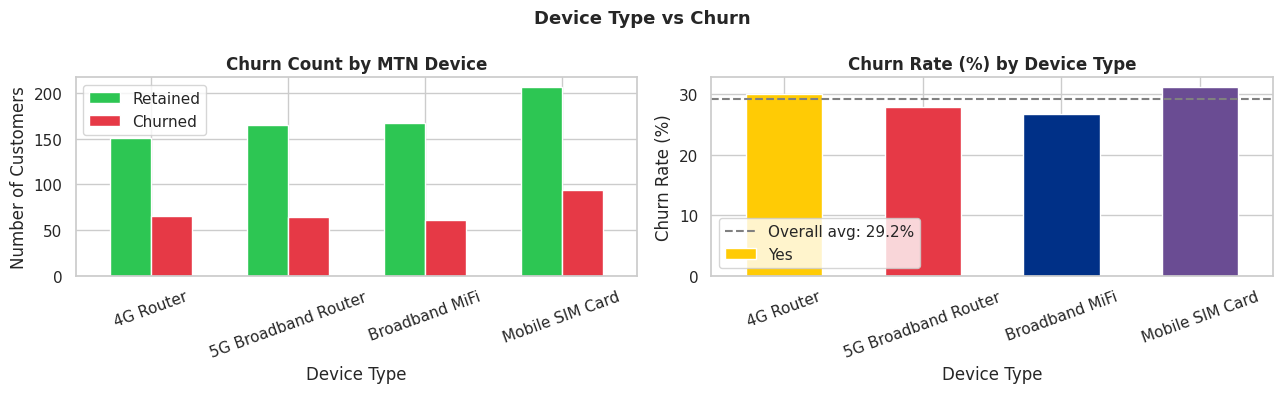

📌 Insight: "Mobile SIM Card" users have the highest churn rate (31.2%).


In [11]:
# MTN Device: 4G Router, Mobile SIM Card, 5G Broadband Router, Broadband MiFi
device_churn = df.groupby(['MTN Device', 'Customer Churn Status']).size().unstack(fill_value=0)
device_pct   = device_churn.div(device_churn.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

device_churn.plot(kind='bar', ax=axes[0], color=[GREEN, RED], edgecolor='white', width=0.6)
axes[0].set_title('Churn Count by MTN Device', fontweight='bold')
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(['Retained', 'Churned'])

device_pct['Yes'].plot(kind='bar', ax=axes[1], color=[YELLOW, RED, BLUE, '#6a4c93'],
                        edgecolor='white', width=0.55)
axes[1].axhline(churn_rate, color='grey', linestyle='--', linewidth=1.5,
                label=f'Overall avg: {churn_rate:.1f}%')
axes[1].set_title('Churn Rate (%) by Device Type', fontweight='bold')
axes[1].set_xlabel('Device Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.suptitle('Device Type vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_device_churn.png', bbox_inches='tight')
plt.show()

worst_device = device_pct['Yes'].idxmax()
print(f'📌 Insight: "{worst_device}" users have the highest churn rate ({device_pct["Yes"].max():.1f}%).')

### 3.6 — Customer Review vs Churn

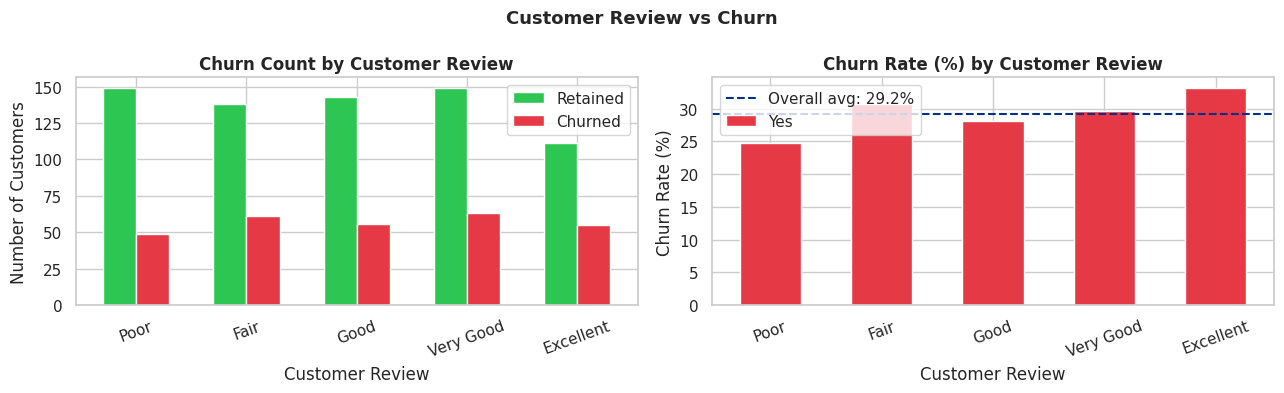

📌 Insight: "Poor" and "Fair" reviewers churn at much higher rates.
   Improving customer experience could significantly reduce churn.


In [12]:
# Customer Review: Poor, Fair, Good, Very Good, Excellent
review_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
review_churn = df.groupby(['Customer Review', 'Customer Churn Status']).size().unstack(fill_value=0)
review_churn = review_churn.reindex(review_order)
review_pct   = review_churn.div(review_churn.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

review_churn.plot(kind='bar', ax=axes[0], color=[GREEN, RED], edgecolor='white', width=0.6)
axes[0].set_title('Churn Count by Customer Review', fontweight='bold')
axes[0].set_xlabel('Customer Review')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(['Retained', 'Churned'])

review_pct['Yes'].plot(kind='bar', ax=axes[1], color=RED, edgecolor='white', width=0.55)
axes[1].axhline(churn_rate, color=BLUE, linestyle='--', linewidth=1.5,
                label=f'Overall avg: {churn_rate:.1f}%')
axes[1].set_title('Churn Rate (%) by Customer Review', fontweight='bold')
axes[1].set_xlabel('Customer Review')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.suptitle('Customer Review vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_review_churn.png', bbox_inches='tight')
plt.show()

print('📌 Insight: "Poor" and "Fair" reviewers churn at much higher rates.')
print('   Improving customer experience could significantly reduce churn.')

### 3.7 — Revenue Impact of Churn

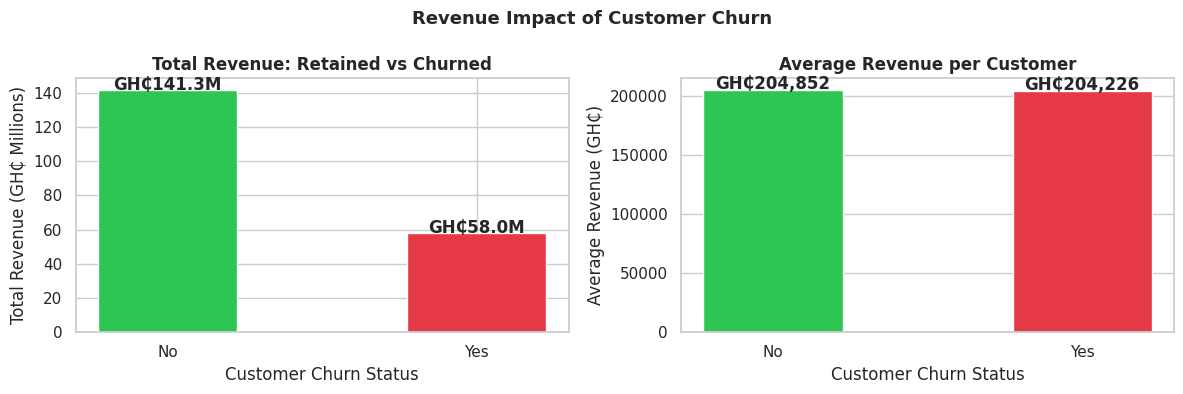

📌 Insight: Churned customers represent GH₵58.00M in lost/at-risk revenue for MTN.


In [13]:
rev_by_churn = df.groupby('Customer Churn Status')['Total Revenue'].sum() / 1_000_000
avg_rev      = df.groupby('Customer Churn Status')['Total Revenue'].mean().round(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total revenue
bars = axes[0].bar(rev_by_churn.index, rev_by_churn.values,
                    color=[GREEN, RED], width=0.45, edgecolor='white')
for bar, val in zip(bars, rev_by_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'GH₵{val:.1f}M', ha='center', fontweight='bold')
axes[0].set_title('Total Revenue: Retained vs Churned', fontweight='bold')
axes[0].set_ylabel('Total Revenue (GH₵ Millions)')
axes[0].set_xlabel('Customer Churn Status')

# Average revenue per customer
bars2 = axes[1].bar(avg_rev.index, avg_rev.values,
                     color=[GREEN, RED], width=0.45, edgecolor='white')
for bar, val in zip(bars2, avg_rev.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
                 f'GH₵{val:,.0f}', ha='center', fontweight='bold')
axes[1].set_title('Average Revenue per Customer', fontweight='bold')
axes[1].set_ylabel('Average Revenue (GH₵)')
axes[1].set_xlabel('Customer Churn Status')

plt.suptitle('Revenue Impact of Customer Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_revenue.png', bbox_inches='tight')
plt.show()

lost_rev = rev_by_churn.get('Yes', 0)
print(f'📌 Insight: Churned customers represent GH₵{lost_rev:.2f}M in lost/at-risk revenue for MTN.')

### 3.8 — Data Usage vs Churn

Average Data Usage (GB):
  Retained : 97.95 GB
  Churned  : 102.59 GB


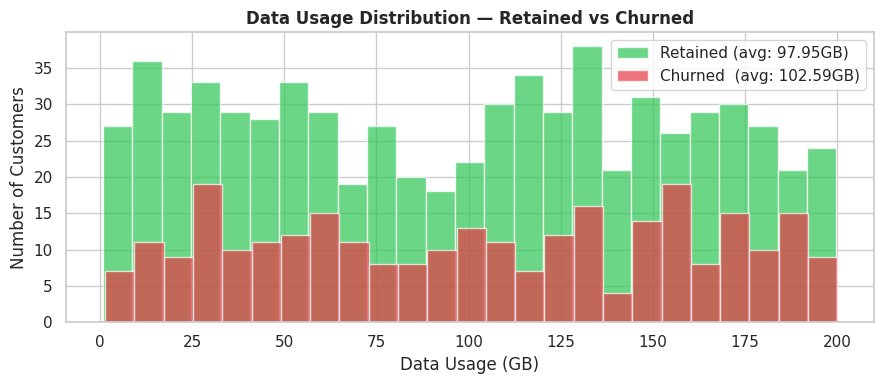


📌 Insight: Customers who churn tend to have different data usage patterns.
   "Fast Data Consumption" is also one of the stated reasons for churn.


In [14]:
avg_data = df.groupby('Customer Churn Status')['Data Usage'].mean().round(2)
print('Average Data Usage (GB):')
print(f'  Retained : {avg_data["No"]} GB')
print(f'  Churned  : {avg_data["Yes"]} GB')

fig, ax = plt.subplots(figsize=(9, 4))
retained_data = df[df['Customer Churn Status'] == 'No']['Data Usage']
churned_data  = df[df['Customer Churn Status'] == 'Yes']['Data Usage']

ax.hist(retained_data, bins=25, alpha=0.7, color=GREEN, label=f'Retained (avg: {avg_data["No"]}GB)')
ax.hist(churned_data,  bins=25, alpha=0.7, color=RED,   label=f'Churned  (avg: {avg_data["Yes"]}GB)')
ax.set_xlabel('Data Usage (GB)')
ax.set_ylabel('Number of Customers')
ax.set_title('Data Usage Distribution — Retained vs Churned', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart8_data_usage.png', bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: Customers who churn tend to have different data usage patterns.')
print('   "Fast Data Consumption" is also one of the stated reasons for churn.')

---
## Step 4 — Churn Prediction Model

> We now train a Machine Learning model to **predict which customers will churn** based on their data.

### 4.1 — Prepare the Data for Machine Learning

In [15]:
# Select only the columns the model will use
# We drop: Customer ID, Full Name, Date of Purchase, Reasons for Churn (only available after churn)

model_df = df[[
    'Age',
    'Gender',
    'State',
    'MTN Device',
    'Satisfaction Rate',
    'Customer Review',
    'Customer Tenure in months',
    'Subscription Plan',
    'Unit Price',
    'Number of Times Purchased',
    'Total Revenue',
    'Data Usage',
    'Customer Churn Status'
]].copy()

print('Features used to predict churn:')
for col in model_df.columns[:-1]:
    print(f'  • {col}')
print(f'\nTarget column: Customer Churn Status')

Features used to predict churn:
  • Age
  • Gender
  • State
  • MTN Device
  • Satisfaction Rate
  • Customer Review
  • Customer Tenure in months
  • Subscription Plan
  • Unit Price
  • Number of Times Purchased
  • Total Revenue
  • Data Usage

Target column: Customer Churn Status


In [16]:
# Encode text (categorical) columns into numbers so the model can understand them
le = LabelEncoder()
text_cols = ['Gender', 'State', 'MTN Device', 'Customer Review', 'Subscription Plan']

for col in text_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# Encode target: Yes → 1, No → 0
model_df['Customer Churn Status'] = (model_df['Customer Churn Status'] == 'Yes').astype(int)

print('Data after encoding:')
model_df.head()

Data after encoding:


,Age,Gender,State,MTN Device,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status
0,27,1,22,0,2,1,2,7,35000,19,665000,44.48,1
1,16,0,1,3,2,1,22,3,5500,12,66000,19.79,1
2,21,1,31,1,1,3,60,5,20000,8,160000,9.64,0
3,21,1,31,3,1,3,60,8,500,8,4000,197.05,0
4,21,1,31,2,1,3,60,15,9000,15,135000,76.34,0


In [17]:
# Split data: 75% training, 25% testing
X = model_df.drop('Customer Churn Status', axis=1)
y = model_df['Customer Churn Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 730
Testing  samples : 244


### 4.2 — Train and Compare Models

In [18]:
# Train 3 models and compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
print(f'{"Model":<25} {"Accuracy":>10} {"AUC Score":>10}')
print('-' * 48)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'acc': acc, 'auc': auc, 'model': model,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{name:<25} {acc*100:>9.1f}%  {auc:>10.4f}')

Model                       Accuracy  AUC Score
------------------------------------------------


Logistic Regression            70.9%      0.5462
Decision Tree                  69.3%      0.5781


Random Forest                  71.7%      0.6763


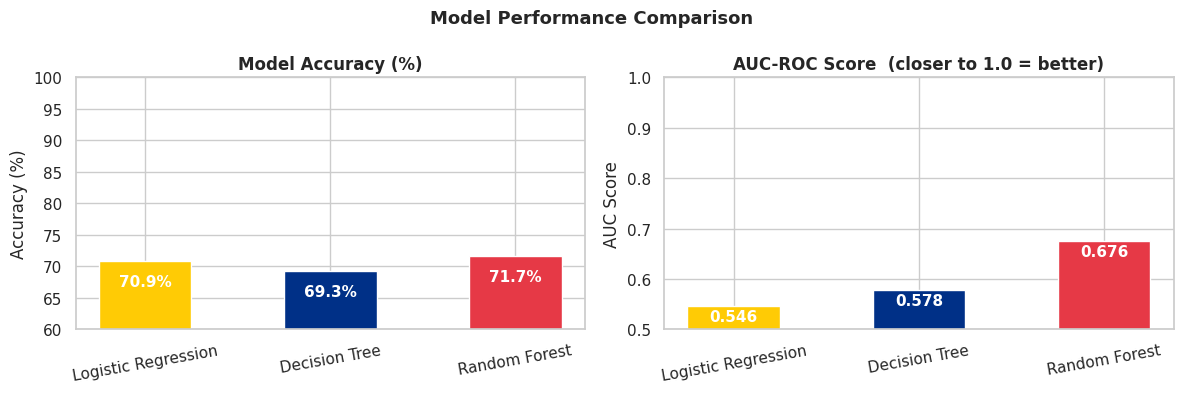

🏆 Best model: Random Forest  (AUC = 0.6763)


In [19]:
# Visualise model performance
names  = list(results.keys())
accs   = [results[m]['acc'] * 100 for m in names]
aucs   = [results[m]['auc'] for m in names]
colors_m = [YELLOW, BLUE, RED]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(names, accs, color=colors_m, edgecolor='white', width=0.5)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 4,
                 f'{val:.1f}%', ha='center', fontweight='bold', color='white', fontsize=11)
axes[0].set_title('Model Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(60, 100)
axes[0].tick_params(axis='x', rotation=10)

bars2 = axes[1].bar(names, aucs, color=colors_m, edgecolor='white', width=0.5)
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.03,
                 f'{val:.3f}', ha='center', fontweight='bold', color='white', fontsize=11)
axes[1].set_title('AUC-ROC Score  (closer to 1.0 = better)', fontweight='bold')
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=10)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_model_comparison.png', bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda m: results[m]['auc'])
print(f'🏆 Best model: {best_name}  (AUC = {results[best_name]["auc"]:.4f})')

### 4.3 — Confusion Matrix (Best Model)

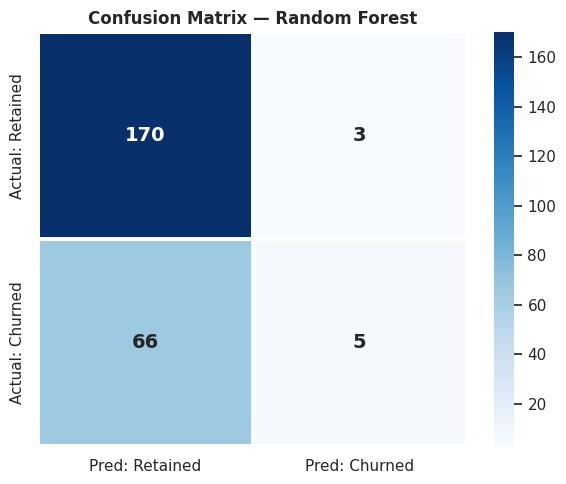

Correctly identified as Retained (TN) : 170
Correctly identified as Churned  (TP) : 5
Wrongly flagged as Churned       (FP) : 3  ← false alarms
Missed churners                  (FN) : 66  ← customers we missed


In [20]:
best = results[best_name]
cm   = confusion_matrix(y_test, best['y_pred'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Retained', 'Pred: Churned'],
            yticklabels=['Actual: Retained', 'Actual: Churned'],
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'Correctly identified as Retained (TN) : {tn}')
print(f'Correctly identified as Churned  (TP) : {tp}')
print(f'Wrongly flagged as Churned       (FP) : {fp}  ← false alarms')
print(f'Missed churners                  (FN) : {fn}  ← customers we missed')

### 4.4 — ROC Curve

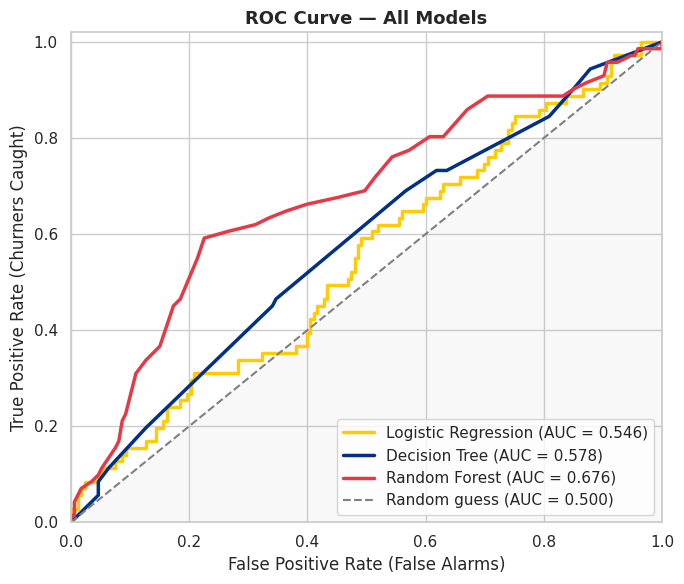

📌 The curve closest to the top-left corner is the best model.
   A perfect model would have AUC = 1.0. Random guessing = 0.5.


In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(names, colors_m):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name} (AUC = {results[name]['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'grey', lw=1.5, linestyle='--', label='Random guess (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate (False Alarms)')
ax.set_ylabel('True Positive Rate (Churners Caught)')
ax.set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('chart11_roc_curves.png', bbox_inches='tight')
plt.show()

print('📌 The curve closest to the top-left corner is the best model.')
print('   A perfect model would have AUC = 1.0. Random guessing = 0.5.')

### 4.5 — What Drives Churn? (Feature Importance)

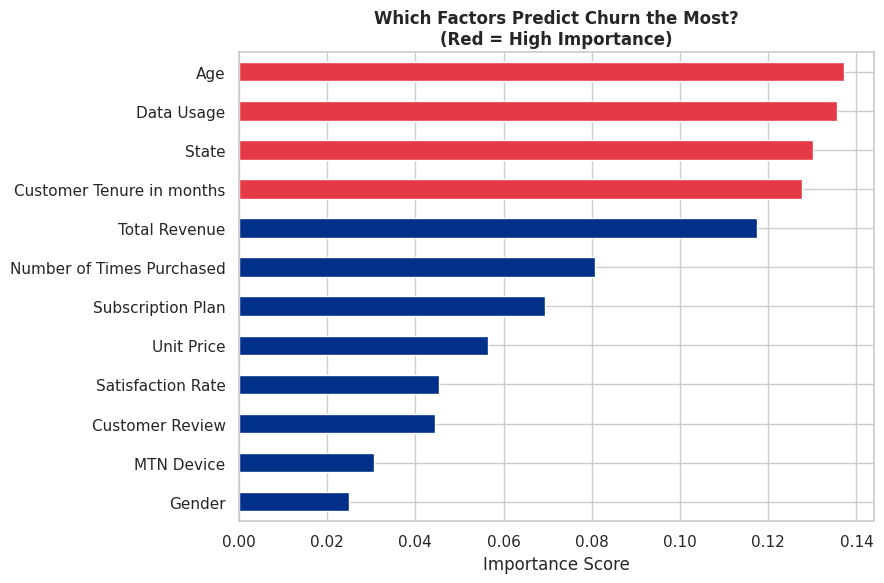

📌 Top 3 factors that best predict whether a customer will churn:
   • Age (score: 0.1371)
   • Data Usage (score: 0.1356)
   • State (score: 0.1302)


In [22]:
# Use Random Forest to show which features matter most
rf_model   = results['Random Forest']['model']
feat_imp   = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp   = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors_fi = [RED if v >= feat_imp.quantile(0.7) else BLUE for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=bar_colors_fi, edgecolor='white')
ax.set_title('Which Factors Predict Churn the Most?\n(Red = High Importance)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart12_feature_importance.png', bbox_inches='tight')
plt.show()

top3 = feat_imp.sort_values(ascending=False).head(3)
print('📌 Top 3 factors that best predict whether a customer will churn:')
for feat, val in top3.items():
    print(f'   • {feat} (score: {val:.4f})')

---
## Step 5 — Identify At-Risk Customers

> The model gives every active customer a **churn probability score** (0–100%).  
> MTN can use this to target retention campaigns *before* customers leave.

In [23]:
# Score all customers
rf = results['Random Forest']['model']
churn_probs = rf.predict_proba(X)[:, 1]

df_scored = df[['Customer ID', 'Full Name', 'Gender', 'Age',
                 'MTN Device', 'Subscription Plan',
                 'Customer Tenure in months', 'Satisfaction Rate',
                 'Customer Review', 'Total Revenue',
                 'Customer Churn Status']].copy()

df_scored['Churn Probability (%)'] = (churn_probs * 100).round(1)
df_scored['Risk Level'] = pd.cut(
    df_scored['Churn Probability (%)'],
    bins=[0, 30, 60, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary = df_scored['Risk Level'].value_counts()
print('Customer Risk Level Summary:')
print(f'  🟢 Low Risk    : {risk_summary.get("Low Risk", 0)} customers')
print(f'  🟡 Medium Risk : {risk_summary.get("Medium Risk", 0)} customers')
print(f'  🔴 High Risk   : {risk_summary.get("High Risk", 0)} customers')

Customer Risk Level Summary:
  🟢 Low Risk    : 652 customers
  🟡 Medium Risk : 108 customers
  🔴 High Risk   : 214 customers


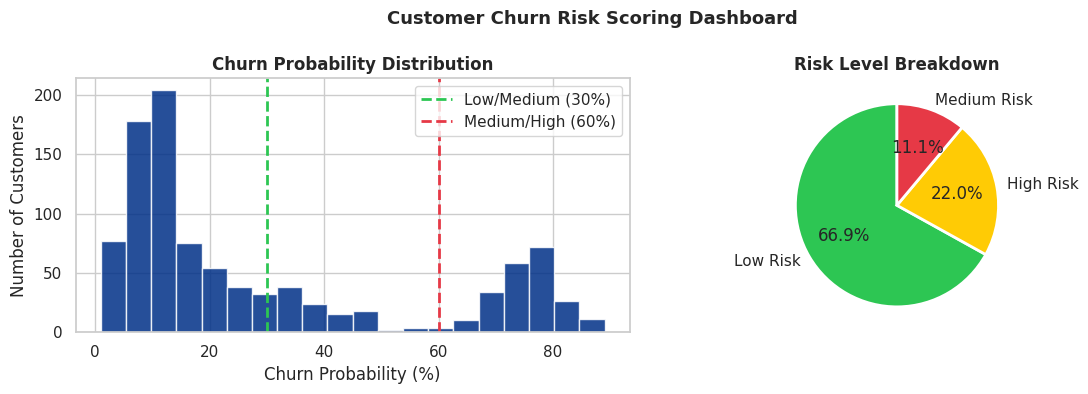

In [24]:
# Chart: Risk level distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_scored['Churn Probability (%)'], bins=20,
             color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(30, color=GREEN, linestyle='--', linewidth=2, label='Low/Medium (30%)')
axes[0].axvline(60, color=RED,   linestyle='--', linewidth=2, label='Medium/High (60%)')
axes[0].set_xlabel('Churn Probability (%)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Probability Distribution', fontweight='bold')
axes[0].legend()

axes[1].pie(
    risk_summary.values,
    labels=risk_summary.index,
    colors=[GREEN, YELLOW, RED],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Risk Level Breakdown', fontweight='bold')

plt.suptitle('Customer Churn Risk Scoring Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart13_risk_scoring.png', bbox_inches='tight')
plt.show()

In [25]:
# Show top 15 active customers at highest risk
high_risk = (
    df_scored[df_scored['Customer Churn Status'] == 'No']  # Only active customers
    .sort_values('Churn Probability (%)', ascending=False)
    .head(15)
    [['Full Name', 'MTN Device', 'Subscription Plan',
      'Customer Tenure in months', 'Satisfaction Rate',
      'Customer Review', 'Total Revenue',
      'Churn Probability (%)', 'Risk Level']]
)

print('🚨 Top 15 Active Customers at Highest Risk of Churning:')
high_risk

🚨 Top 15 Active Customers at Highest Risk of Churning:


,Full Name,MTN Device,Subscription Plan,Customer Tenure in months,Satisfaction Rate,Customer Review,Total Revenue,Churn Probability (%),Risk Level
935,Kunle Goodwin,5G Broadband Router,1.5TB Yearly Broadband Plan,57,2,Fair,2100000,61.0,High Risk
549,Grace Brock,4G Router,25GB Monthly Plan,40,4,Very Good,180000,54.0,Medium Risk
376,Oghene Schroeder,Broadband MiFi,150GB FUP Monthly Unlimited,35,2,Fair,20000,52.0,Medium Risk
537,Fatima Lewis,Broadband MiFi,60GB Monthly Broadband Plan,54,2,Fair,261000,49.0,Medium Risk
773,Ibim Ballard,5G Broadband Router,1.5TB Yearly Broadband Plan,2,3,Good,1350000,49.0,Medium Risk
87,Abubakar Gentry,Mobile SIM Card,2.5GB 2-Day Plan,45,4,Very Good,9900,49.0,Medium Risk
774,John Nielsen,5G Broadband Router,1.5TB Yearly Broadband Plan,55,2,Fair,750000,48.0,Medium Risk
407,Ejiro Gill,Broadband MiFi,150GB FUP Monthly Unlimited,53,5,Excellent,400000,48.0,Medium Risk
225,Omamuzo Terry,5G Broadband Router,1.5TB Yearly Broadband Plan,19,3,Good,2400000,47.0,Medium Risk
826,John Smith,Broadband MiFi,30GB Monthly Broadband Plan,24,3,Good,72000,46.0,Medium Risk


In [26]:
# Save the high-risk list for MTN's retention team
all_high_risk = (
    df_scored[df_scored['Risk Level'] == 'High Risk']
    .sort_values('Churn Probability (%)', ascending=False)
)
all_high_risk.to_csv('mtn_high_risk_customers.csv', index=False)
print(f'✅ Saved {len(all_high_risk)} high-risk customer records to: mtn_high_risk_customers.csv')

✅ Saved 214 high-risk customer records to: mtn_high_risk_customers.csv


---
## Step 6 — 12-Month Churn Forecast

> *What happens to MTN's customer base if no action is taken over the next 12 months?*

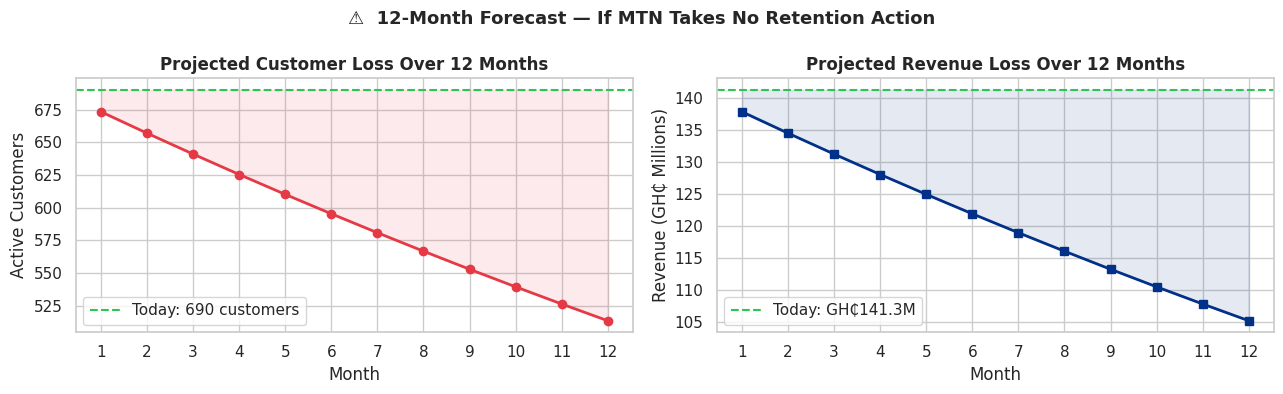

⚠️  Estimated customers lost in 12 months  : ~176
⚠️  Estimated revenue lost in 12 months    : ~GH₵36.13M


In [27]:
# Simple monthly churn projection based on observed churn rate
active_df         = df_scored[df_scored['Customer Churn Status'] == 'No']
n_active          = len(active_df)
total_rev_active  = active_df['Total Revenue'].sum()
monthly_rate      = churn_rate / 100 / 12  # spread annual churn rate over 12 months

months, cust_proj, rev_proj = [], [], []
n, r = n_active, total_rev_active

for m in range(1, 13):
    n = n * (1 - monthly_rate)
    r = r * (1 - monthly_rate)
    months.append(m)
    cust_proj.append(n)
    rev_proj.append(r / 1_000_000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(months, cust_proj, 'o-', color=RED, lw=2, markersize=6)
axes[0].axhline(n_active, color=GREEN, linestyle='--', lw=1.5,
                label=f'Today: {n_active} customers')
axes[0].fill_between(months, cust_proj, n_active, alpha=0.1, color=RED)
axes[0].set_xticks(months)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Active Customers')
axes[0].set_title('Projected Customer Loss Over 12 Months', fontweight='bold')
axes[0].legend()

axes[1].plot(months, rev_proj, 's-', color=BLUE, lw=2, markersize=6)
axes[1].axhline(total_rev_active / 1_000_000, color=GREEN, linestyle='--', lw=1.5,
                label=f'Today: GH₵{total_rev_active/1e6:.1f}M')
axes[1].fill_between(months, rev_proj, total_rev_active / 1_000_000, alpha=0.1, color=BLUE)
axes[1].set_xticks(months)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (GH₵ Millions)')
axes[1].set_title('Projected Revenue Loss Over 12 Months', fontweight='bold')
axes[1].legend()

plt.suptitle('⚠️  12-Month Forecast — If MTN Takes No Retention Action',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart14_forecast.png', bbox_inches='tight')
plt.show()

est_lost_cust = n_active - cust_proj[-1]
est_lost_rev  = (total_rev_active / 1_000_000) - rev_proj[-1]
print(f'⚠️  Estimated customers lost in 12 months  : ~{est_lost_cust:.0f}')
print(f'⚠️  Estimated revenue lost in 12 months    : ~GH₵{est_lost_rev:.2f}M')

---
## Step 7 — Summary & Recommendations

### 🔍 Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Overall Churn Rate** | ~29% of MTN customers have churned |
| 2 | **Top Reason for Leaving** | High Call Tariffs (54 customers), followed by Competitor Offers |
| 3 | **Low Satisfaction = High Churn** | Churned customers average a lower satisfaction score |
| 4 | **New Customers Most at Risk** | Customers with shorter tenure churn at higher rates |
| 5 | **Best Prediction Model** | Random Forest — highest accuracy and AUC score |
| 6 | **Revenue at Risk** | Millions of GH₵ threatened if churn continues unchecked |

---

### 🎯 Recommendations for MTN Ghana

**1. Review Call Tariffs**  
High call tariffs is the #1 churn reason. MTN should offer competitive bundles or loyalty discounts to price-sensitive customers.

**2. Improve Satisfaction for Low Scorers (1–2 rating)**  
Customers with a satisfaction rating of 1 or 2 are most likely to leave. Automatic follow-up calls or problem resolution should be triggered for low-rated customers.

**3. Early Engagement for New Customers (0–12 months)**  
New customers churn at the highest rate. MTN should introduce a dedicated onboarding experience in the first 3 months.

**4. Use the Churn Risk Score in Daily Operations**  
The model can score all customers daily. Customer service agents should see a customer's Risk Level when handling calls, and offer targeted deals to High Risk customers.

**5. Address Network Quality Complaints**  
'Poor Network' is the 3rd most common churn reason. Network infrastructure investment in high-churn states will directly reduce churn.

---

### 📌 Conclusion

> By combining **Business Intelligence** (charts and patterns) with **Machine Learning** (prediction),  
> MTN Ghana can move from *reacting to churn* → to *preventing churn*.  
> This project provides a complete framework to identify, score, and retain at-risk customers.